In [2]:
import numpy as np
import sounddevice as sd
import scipy.signal as signal
import matplotlib.pyplot as plt
from scipy.optimize import minimize_scalar

def generate_sweep(fs, duration, f_start, f_end):
    t = np.linspace(0, duration, int(fs * duration), endpoint=False)
    sweep = signal.chirp(t, f0=f_start, f1=f_end, t1=duration, method='logarithmic')
    return t, sweep

def measure_system_response(fs, duration, f_start, f_end, input_gain=0.1):
    print("Generating sweep...")
    t, sweep = generate_sweep(fs, duration, f_start, f_end)
    sweep = sweep * input_gain

    print(sd.query_devices())

    print("Playing and recording...")
    recording = sd.playrec(sweep, samplerate=fs, channels=2, dtype='float64')
    sd.wait()
    print("Done recording.")

    return recording[:, 1], recording[:, 0]

def compute_transfer_function_fft(input_signal, output_signal, fs):
    N = len(input_signal)
    window = np.hanning(N)
    input_windowed = input_signal * window
    output_windowed = output_signal * window

    X = np.fft.rfft(input_windowed)
    Y = np.fft.rfft(output_windowed)
    freqs = np.fft.rfftfreq(N, d=1/fs)

    X = np.where(np.abs(X) < 1e-12, 1e-12, X)
    H = Y / X
    return freqs, H

def iir_filter_response(b, a, freqs, fs):
    w = 2 * np.pi * freqs / fs
    _, h = signal.freqz(b, a, worN=w)
    return h

def peaking_eq_biquad(f0, Q, gain_db, fs):
    A = 10**(gain_db / 40)
    w0 = 2 * np.pi * f0 / fs
    alpha = np.sin(w0) / (2 * Q)

    b0 = 1 + alpha * A
    b1 = -2 * np.cos(w0)
    b2 = 1 - alpha * A
    a0 = 1 + alpha / A
    a1 = -2 * np.cos(w0)
    a2 = 1 - alpha / A

    b = np.array([b0, b1, b2]) / a0
    a = np.array([1.0, a1 / a0, a2 / a0])
    return b, a

def fit_peaking_eq_q_only(freqs, target_H, fs, fit_freq_range=None):
    if fit_freq_range is not None:
        fmin, fmax = fit_freq_range
        mask = (freqs >= fmin) & (freqs <= fmax)
        freqs_fit = freqs[mask]
        target_H_fit = target_H[mask]
    else:
        freqs_fit = freqs
        target_H_fit = target_H

    mags = np.abs(target_H_fit)
    min_idx = np.argmin(mags)
    min_gain = 20 * np.log10(mags[min_idx])
    f0 = freqs_fit[min_idx]
    gain_db = min_gain

    def q_objective(Q):
        if Q <= 0.05 or Q > 50:
            return 1e6

        b, a = peaking_eq_biquad(f0, Q, gain_db, fs)
        w = 2 * np.pi * freqs_fit / fs
        _, H_fit = signal.freqz(b, a, worN=w)
        error = np.abs(H_fit) - np.abs(target_H_fit)
        return np.sum(error**2)

    result = minimize_scalar(q_objective, bounds=(0.1, 50), method='bounded')
    Q_opt = result.x
    return f0, Q_opt, gain_db


fs = 44100
duration = 20
f_start = 5
f_end = 10000
filter_order = 16

input_signal, output_signal = measure_system_response(fs, duration, f_start, f_end)
freqs, H_measured = compute_transfer_function_fft(input_signal, output_signal, fs)

valid = (freqs >= f_start) & (freqs <= f_end)
freqs = freqs[valid]
H_measured = H_measured[valid]

fit_freq_range = (15, 300)
f0, Q, gain_db = fit_peaking_eq_q_only(freqs, H_measured, fs, fit_freq_range)
b_fit, a_fit = peaking_eq_biquad(f0, Q, gain_db, fs)
_, H_fit = signal.freqz(b_fit, a_fit, worN=2 * np.pi * freqs / fs)

print(f"Fitted Peaking EQ:\n  f0 = {f0:.1f} Hz\n  Q = {Q:.2f}\n  Gain = {gain_db:.2f} dB")



Generating sweep...
>  0 Teensy MIDI_Audio, Core Audio (2 in, 0 out)
<  1 Teensy MIDI_Audio, Core Audio (0 in, 2 out)
   2 MacBook Pro Microphone, Core Audio (1 in, 0 out)
   3 MacBook Pro Speakers, Core Audio (0 in, 2 out)
   4 Microsoft Teams Audio, Core Audio (1 in, 1 out)
   5 ZoomAudioDevice, Core Audio (2 in, 2 out)
   6 Teensy & HP, Core Audio (0 in, 0 out)
   7 Aggregate Device, Core Audio (0 in, 0 out)
   8 Teensy and Speakers, Core Audio (0 in, 2 out)
   9 teensy io combined, Core Audio (0 in, 0 out)
  10 HaptiCoupler n Speakers, Core Audio (2 in, 4 out)
Playing and recording...
Done recording.
Fitted Peaking EQ:
  f0 = 93.8 Hz
  Q = 3.07
  Gain = -26.34 dB


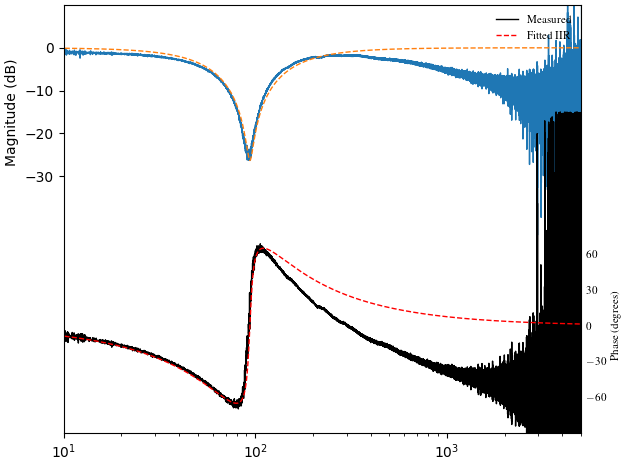

In [3]:
import scienceplots


fig, ax = plt.subplots()
plt.style.use(['science','ieee'])
ax.set_xlim([10, 5000])

ax.semilogx(freqs, 20*np.log10(np.abs(H_measured)), label='Measured')
ax.semilogx(freqs, 20*np.log10(np.abs(H_fit)), '--', label='Fitted IIR')
ax.set_ylabel("Magnitude (dB)")
ax.set_ylim([-90, 10])
ax.set_yticks([-30, -20, -10, 0])
ax.set_yticks([],minor=True)
ax.yaxis.label.set_position((0.0, 0.75))

ax2 = ax.twinx()
ax2.semilogx(freqs, np.angle(H_measured, deg=True), label='Measured')
ax2.semilogx(freqs, np.angle(H_fit, deg=True), '--', label='Fitted IIR')
ax2.set_xlabel("Frequency (Hz)")
ax2.set_ylabel("Phase (degrees)")
ax2.set_ylim([-90, 270])
ax2.set_yticks([-60, -30, 0, 30, 60])
ax2.set_yticks([],minor=True)
ax2.yaxis.label.set_position((0.0, 0.25))
#ax2.legend()
plt.grid(True)

plt.legend()
plt.grid(False)


plt.tight_layout()
plt.show()
